In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from adjustText import adjust_text
from statannotations.Annotator import Annotator
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

In [2]:
tcga_path = 'data/tcga_mut_somaticgermline.tsv'
roles_path = 'data/generoles.tsv'
bands_path = 'data/genebands.tsv'
pancan_path = 'data/pancan_twohitfreq.tsv'
tumor_path = 'data/tumor_twohitfreq.tsv'
genes_path = 'data/gene-coordinates_hg38.tsv'

In [3]:
tcga = pd.read_csv(tcga_path, sep = '\t')
roles = pd.read_csv(roles_path, sep = '\t')
bands = pd.read_csv(bands_path, sep = '\t')
pancan = pd.read_csv(pancan_path, sep = '\t')
tumor = pd.read_csv(tumor_path, sep = '\t')
genes = pd.read_csv(genes_path, sep = '\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 1E

In [7]:
# calculating pancancer 2 hit frequencies

tcgazf = tcga[tcga.midan_filter=='keep']
tcgazf_nosil = tcgazf[tcgazf.Variant_Classification!='Silent']
pancan2hitfreqs = tcgazf_nosil.groupby(['Hugo_Symbol','zygosity'])['tissue'].nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index='Hugo_Symbol',columns='zygosity',values='counts').fillna(0).reset_index()
pancan2hitfreqs['tot'] = pancan2hitfreqs['1-hit']+pancan2hitfreqs['2-hit']
print(len(pancan2hitfreqs))
pancan2hitfreqs = pancan2hitfreqs[pancan2hitfreqs.tot>=5]
print(len(pancan2hitfreqs))
pancan2hitfreqs['2hitfreq'] = pancan2hitfreqs['2-hit']/pancan2hitfreqs['tot']

print(len(pancan2hitfreqs))
pancan2hitfreqs = pd.merge(pancan2hitfreqs,roles, on='Hugo_Symbol', how='left')
pancan2hitfreqs = pd.merge(pancan2hitfreqs,bands, on='Hugo_Symbol', how='left')
print(len(pancan2hitfreqs))

pancan2hitfreqs_tsgs = pancan2hitfreqs[pancan2hitfreqs.role=='TSG']

pancan2hitfreqs

19209
17514
17514
17514


,Hugo_Symbol,1-hit,2-hit,tot,2hitfreq,role,arm
0,A1BG,25.0,0.0,25.0,0.000000,other,chr19q
1,A1CF,46.0,16.0,62.0,0.258065,ambiguous,NaN
2,A2M,78.0,8.0,86.0,0.093023,other,chr12p
3,A2ML1,77.0,8.0,85.0,0.094118,other,chr12p
4,A4GALT,13.0,1.0,14.0,0.071429,other,chr22q
...,...,...,...,...,...,...,...
17509,ZYG11A,9.0,1.0,10.0,0.100000,other,chr1p
17510,ZYG11B,24.0,1.0,25.0,0.040000,other,chr1p
17511,ZYX,26.0,0.0,26.0,0.000000,other,chr7q
17512,ZZEF1,61.0,30.0,91.0,0.329670,other,chr17p


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


KstestResult(statistic=0.3099579242636746, pvalue=1.1227084039109715e-11, statistic_location=0.14736842105263157, statistic_sign=1)
KstestResult(statistic=0.2660861151427189, pvalue=2.08420921908464e-07, statistic_location=0.14705882352941177, statistic_sign=1)


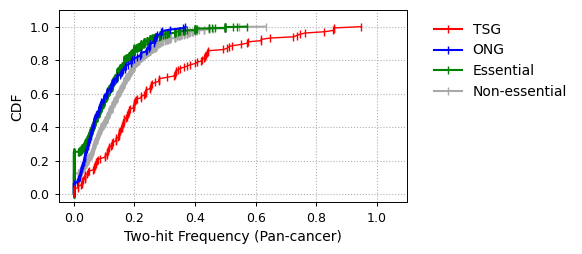

In [8]:
config_rcparams()

plt.figure(figsize=(4.5,2.5))

#data = pancan2hitfreqs[pancan2hitfreqs.role.isin(['other','nonessential'])]['2hitfreq'].values
data = pancan2hitfreqs[pancan2hitfreqs.role == 'nonessential']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', color='darkgrey') 

data = pancan2hitfreqs[pancan2hitfreqs.role=='essential']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', color='green') 

data = pancan2hitfreqs[pancan2hitfreqs.role=='ONG']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', color='blue') 

data = pancan2hitfreqs[pancan2hitfreqs.role=='TSG']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', linewidth=1, color='red', label='TSG') 

legend_elements = [Line2D([0], [0], linestyle='-', marker='|', color='red', label='TSG'),
                   Line2D([0], [0], linestyle='-', marker='|', color='blue', label='ONG'),
                   Line2D([0], [0], linestyle='-', marker='|', color='green', label='Essential'),
                   Line2D([0], [0], linestyle='-', marker='|', color='darkgrey', label='Non-essential')]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.04, 1),frameon=False)


plt.grid(True, linestyle=':')
plt.xlim(-0.05,1.10)
plt.ylim(-0.05,1.10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('Two-hit Frequency (Pan-cancer)',fontsize=10)
plt.ylabel('CDF',fontsize=10)

print(stats.kstest( pancan2hitfreqs[pancan2hitfreqs.role.isin(['other','nonessential'])]['2hitfreq'].values,pancan2hitfreqs[pancan2hitfreqs.role=='TSG']['2hitfreq'].values))
print(stats.kstest( pancan2hitfreqs[pancan2hitfreqs.role.isin(['nonessential'])]['2hitfreq'].values,pancan2hitfreqs[pancan2hitfreqs.role=='TSG']['2hitfreq'].values))

plt.show()

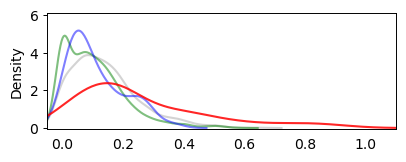

In [9]:
config_rcparams()

plt.figure(figsize=(4.5,1.5))

#data = pancan2hitfreqs[pancan2hitfreqs.role.isin(['other','nonessential'])]['2hitfreq'].values
data = pancan2hitfreqs[pancan2hitfreqs.role=='nonessential']['2hitfreq'].values
ax = sns.kdeplot(data, color='darkgrey', alpha=0.5)
data = pancan2hitfreqs[pancan2hitfreqs.role=='essential']['2hitfreq'].values
ax = sns.kdeplot(data, color='green', alpha=0.5)
data = pancan2hitfreqs[pancan2hitfreqs.role=='ONG']['2hitfreq'].values
ax = sns.kdeplot(data, color='blue', alpha=0.5)
data = pancan2hitfreqs[pancan2hitfreqs.role=='TSG']['2hitfreq'].values
ax = sns.kdeplot(data, color='red', alpha=0.85)

#plt.grid(True, linestyle=':')
plt.ylabel('Density',fontsize=10)
plt.xlim(-0.05,1.10)
plt.ylim(-0.05,6.10)
ax.tick_params(bottom=False) 

---

# Fig 3E

In [10]:
# preparing dataset

tmp = bands.drop_duplicates(subset=['arm'], keep='first')[:40][['arm']].reset_index(drop=True)
tmp.loc[31] = 'chr18p'
tmp.loc[32] = 'chr18q'
tmp['index'] = [1,2,4,3,6,5,7,8,9,10,12,11,13,14,15,16,18,17,20,19,22,21,24,23,25,26,27,28,29,31,30,32,33,35,34,36,37,39,38,40]
tmp = tmp.sort_values(by=['index'])
custom_order = tmp['arm'].values.tolist()
custom_order.remove('chr21p') #this excludes small arms of all acrocentric chormosomes 13, 14, 15, 21, 22 

# above didn't work, hence setting manually:
custom_order = ['chr1p','chr1q','chr2p','chr2q','chr3p','chr3q','chr4p','chr4q','chr5p','chr5q',
                'chr6p','chr6q','chr7p','chr7q','chr8p','chr8q','chr9p','chr9q','chr10p','chr10q',
                'chr11p','chr11q','chr12p','chr12q','chr13q','chr14q','chr15q','chr16p','chr16q',
                'chr17p','chr17q','chr18p','chr18q','chr19p','chr19q','chr20p','chr20q','chr21q','chr22q']

# removing 'chr'
custom_order_mod = []
for i in custom_order:
    custom_order_mod.append(i[3:])
    

tmpdf = pancan2hitfreqs.copy()
print(tmpdf.role.value_counts())
tmpdf['role'] = tmpdf['role'].replace('nonessential','other') # clubbing nonessential and other genes
print(tmpdf.role.value_counts())

# separating gene roles
data1 = tmpdf[tmpdf.role == 'other'].copy()
data1['arm'] = pd.Categorical(data1['arm'], categories=custom_order, ordered=True)
data1 = data1.sort_values(by='arm').dropna()

data2 = tmpdf[tmpdf.role == 'essential'].copy()
data2['arm'] = pd.Categorical(data2['arm'], categories=custom_order, ordered=True)
data2 = data2.sort_values(by='arm').dropna()

data3 = tmpdf[tmpdf.role.isin(['TSG','ONG'])].copy()
data3['arm'] = pd.Categorical(data3['arm'], categories=custom_order, ordered=True)
data3 = data3.sort_values(by='arm').dropna()

# removing 'chr'
data1['arm'] = data1['arm'].apply(lambda x:x[3:])
data2['arm'] = data2['arm'].apply(lambda x:x[3:])
data3['arm'] = data3['arm'].apply(lambda x:x[3:])

other           12145
ambiguous        1776
essential        1236
nonessential      689
TSG               132
ONG               115
Name: role, dtype: int64
other        12834
ambiguous     1776
essential     1236
TSG            132
ONG            115
Name: role, dtype: int64


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


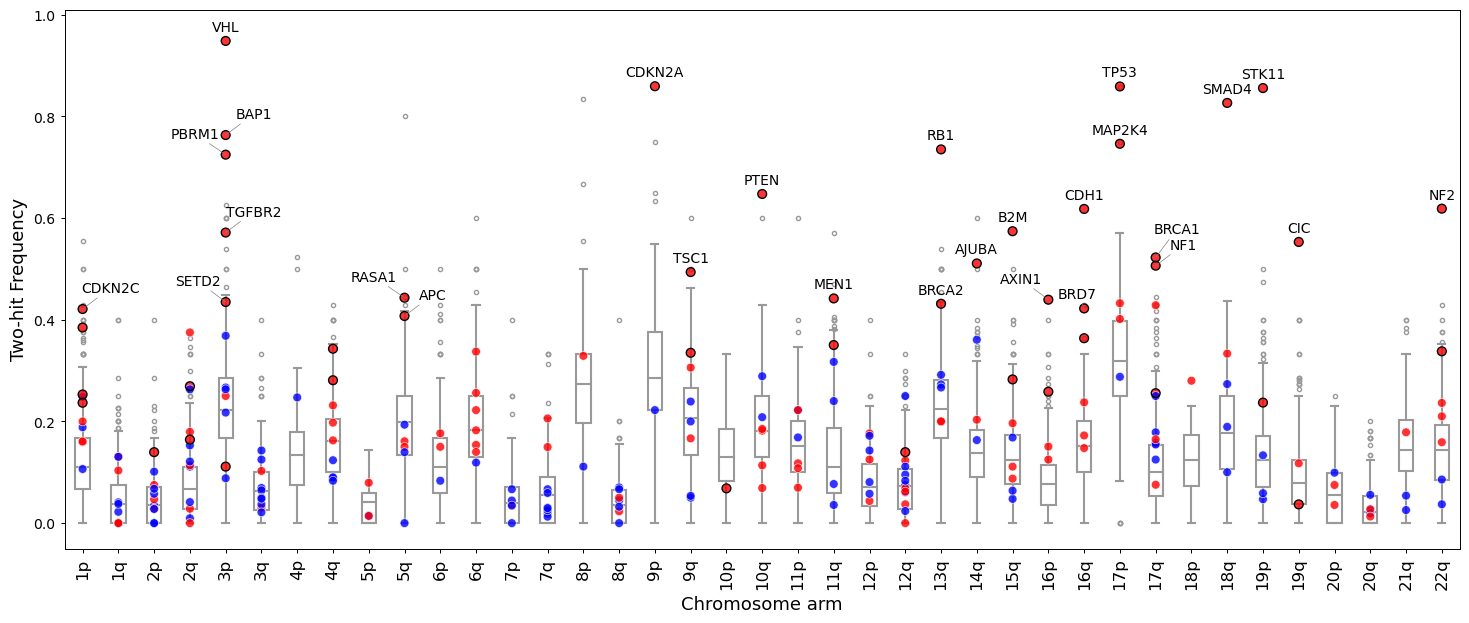

In [11]:
config_rcparams()

plt.figure(figsize=(18,7))

genes_to_annotate = {
    "CDKN2C": (20, 5),
    "BAP1": (20,5),
    "RASA1": (-22,5),
    "APC": (20,5),
    "PBRM1": (-22,5),
    "TGFBR2": (20,5),
    "SETD2": (-20,5),
    "BRCA1": (15,10),
    "NF1": (20,5),
    "NCOR1": (-20,25),
    "FLCN": (15,8),
    "PRKAR1A": (25,2),
    "AXIN1": (-20,5),
    "BRD7":(-5,0)
}

# plot

ax = sns.boxplot(data=data1, y='2hitfreq', x='arm', color='white', width=0.4, zorder=1, flierprops={"marker": "o","markerfacecolor":"None"}, fliersize=3)
ax = sns.scatterplot(data=data3, y='2hitfreq', x='arm', hue='role', palette={'TSG': 'red', 'ONG': 'blue','':'white'}, s=40, zorder=2, legend=False, alpha=0.8)

# outline significant tsgs

psig = pancan[pancan['FDR']<0.05]['Hugo_Symbol'].unique()
tsig = tumor[tumor['FDR']<0.05]['Hugo_Symbol'].unique()
high = pancan2hitfreqs_tsgs[pancan2hitfreqs_tsgs['2hitfreq']>0.4]['Hugo_Symbol'].unique()

outline = data3[(data3.Hugo_Symbol.isin(psig))]
ax = sns.scatterplot(data=outline, y='2hitfreq', x='arm', s=40, zorder=3, legend=False, marker='o', facecolor='none', edgecolor='k', linewidth=1)


# annotate dots

x_lookup = {arm: pos for pos, arm in enumerate(custom_order_mod)}
#sel = data3.query("role == 'TSG' and `2hitfreq` > 0.4")
label = data3[(data3.Hugo_Symbol.isin(psig))&(data3.Hugo_Symbol.isin(high))]
sel = label

texts = []

for _, row in sel.iterrows():
    x = x_lookup[row['arm']]
    y = row['2hitfreq']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=10,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=10,
            ha="center", va="bottom",          
        )


        
# axes
plt.xticks(rotation = 90,fontsize=12)
plt.ylabel('Two-hit Frequency',fontsize=13)
plt.xlabel('Chromosome arm',fontsize=13)
plt.ylim(-0.05, 1.01)

plt.show()

---

# Fig S6A

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

10p_other vs. 10p_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:1.338e-01 U_stat=9.380e+02
10q_other vs. 10q_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:2.265e-01 U_stat=6.988e+03
11p_other vs. 11p_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:1.918e-02 U_stat=5.539e+03
11q_other vs. 11q_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:1.068e-06 U_stat=2.232e+04
12p_other vs. 12p_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:1.860e-01 U_stat=2.022e+03
12q_other vs. 12q_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:9.826e-02 U_stat=1.839e+04
13q_other vs. 13q_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:7.536e-01 U_stat=2.325e+03
14q_other vs. 14q_essential: Mann-Whitney-Wilcoxon test two-sided, P_val:8.874e-02 U_stat=1.321e+04
15q_othe

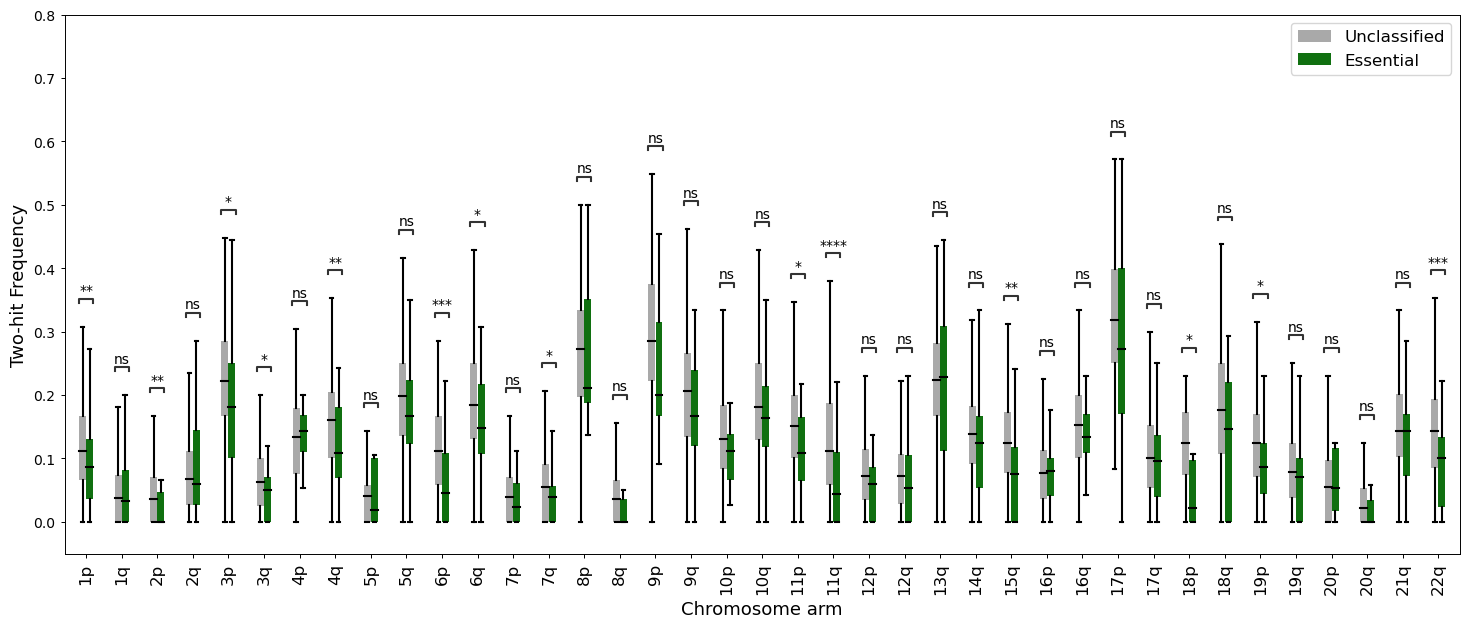

In [12]:
config_rcparams()

plt.figure(figsize=(18,7))

PROPS = {
    'boxprops':{'edgecolor':'none'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

data=pd.concat([data1,data2])
ax = sns.boxplot(data=data, y='2hitfreq', x='arm', hue='role', width=0.4,showfliers=False, **PROPS, palette=['darkgrey','green'])#, linecolor='white')


arms = data['arm'].unique()

pairs = []
for arm in sorted(arms):
    pairs.append(((arm, 'other'), (arm, 'essential')))
    
annotator = Annotator(ax, pairs, data=data, x='arm', y='2hitfreq', hue='role')


annotator.configure(
    test='Mann-Whitney',
    text_format='star',
    loc='inside',
    comparisons_correction=None,
    line_offset=-0.05,   # moves bracket down
    line_height=0.01,    # shortens bracket height
    verbose=1
)

annotator.apply_and_annotate()

plt.xticks(rotation = 90,fontsize=12)
plt.ylabel('Two-hit Frequency',fontsize=13)
plt.xlabel('Chromosome arm',fontsize=13)
plt.ylim(-0.05, 0.8)

handles, labels = ax.get_legend_handles_labels()
new_labels = ["Unclassified", "Essential"] 
legend = ax.legend(handles, new_labels, title=None, fontsize=12)
for handle in legend.legendHandles:
    handle.set_edgecolor('none')

plt.show()

---

# Fig 3F

SignificanceResult(statistic=0.7995402993410963, pvalue=1.742171701773821e-09)


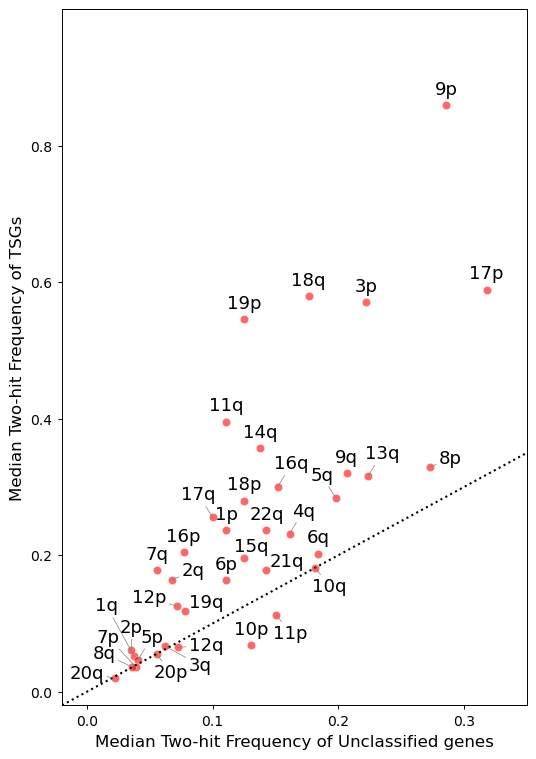

In [13]:
config_rcparams()

plt.figure(figsize=(6,9.04))

arms_to_annotate = {
    "13q": (10, 5),
    "19q": (15, -5),
    "5q": (-10, 5),
    "10q": (10, -25),
    "11p": (10, -25),
    "4q": (10, 5),
    "16q": (10, 5),
    "17q": (-10, 5),
    "21q": (15, -5),
    "15q": (5, -3),
    "2q": (15, -5),
    "12p": (-20, -5),
    "8p": (15, -5),
    "3q": (-20, -5),
    "20q": (-20, -8),
    "20p": (10, -25),
    "3q": (25, -25),
    "12q": (20, -10),
    "1q": (-20, 25),
    "8q": (-20, -2),
    "5p": (10, 5),
    "2p": (0, 5),
    "7p": (-20, 10)
}


data = pd.concat([data1,data3])
data = data[data.role!='ONG'].groupby(['role','arm'])['2hitfreq'].median().to_frame().reset_index().pivot(index='arm',columns='role',values='2hitfreq').reset_index()
ax = sns.scatterplot(data=data,x='other',y='TSG', color='red', alpha=0.6)

ax.plot([-10, 110], [-10, 110],color='k',linestyle=':')

sel=data
for _, row in sel.iterrows():
    x, y = row['other'], row['TSG']
    label = row['arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=13,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=13,
            ha="center", va="bottom",          
        )


plt.xlabel('Median Two-hit Frequency of Unclassified genes', fontsize=12)
plt.ylabel('Median Two-hit Frequency of TSGs', fontsize=12)
ax.set_xticks([0.0,0.1,0.2,0.3,0.4])
ax.set_yticks([0.0,0.2,0.4,0.6,0.8])
#plt.title('Median Two-hit Frequency')
plt.xlim(-0.02,0.35)
#plt.xlim(-0.02,1)
plt.ylim(-0.02,1)

print(stats.spearmanr(data['other'].values,data['TSG'].values, nan_policy='omit'))

plt.show()

---

# Fig S6B

SignificanceResult(statistic=0.9370441845460672, pvalue=1.7212968904019147e-18)


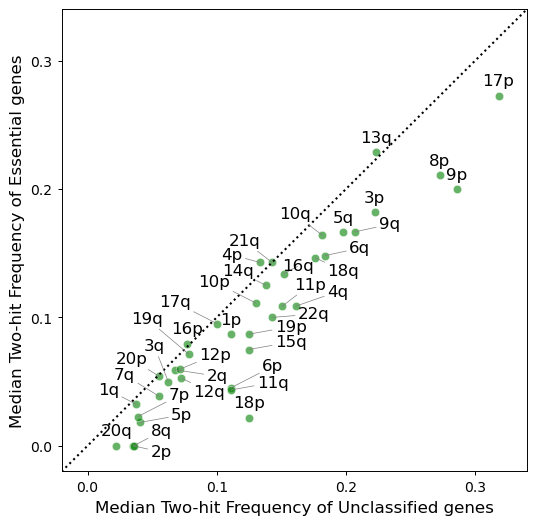

In [14]:
config_rcparams()

plt.figure(figsize=(6,6))

arms_to_annotate = {
    "10q": (-20, 5),
    "9q": (25, -5),
    "6q": (25, -5),
    "21q": (-20, 5),
    "16q": (10, -5),
    "18q": (20, -20),
    "4p": (-20, -5),
    "14q": (-20, 0),
    "10p": (-30, 5),
    "17q": (-30, 5),
    "19q": (-30, 15),
    "1q": (-20, 0),
    "7q": (-25, 5),
    "11p": (20, 5),
    "4q": (30, 0),
    "19p": (30, -5),
    "22q": (30, -8),
    "15q": (30, -5),
    "6p": (30, 5),
    "11q": (30, -5),
    "12q": (20, -20),
    "2p": (20, -15),
    "20p": (-20, 2),
    "2q": (-25, -15),
    "7p": (30, 5),
    "5p": (30, -5),
    "8q": (20, 0),
    "3q": (-10, 15),
    "2q": (30, -15),
    "12p": (25, 0)
}

data=pd.concat([data1,data2]).groupby(['role','arm'])['2hitfreq'].median().to_frame().reset_index().pivot(index='arm',columns='role',values='2hitfreq').reset_index()

ax = sns.scatterplot(data=data,x='other',y='essential', color='green', alpha=0.6)

sel=data
for _, row in sel.iterrows():
    x, y = row['other'], row['essential']
    label = row['arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=12,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=12,
            ha="center", va="bottom",          
        )

    
ax.plot([-10, 110], [-10, 110],color='k',linestyle=':')

plt.xlim(-0.02,0.34)
plt.ylim(-0.02,0.34)
plt.xlabel('Median Two-hit Frequency of Unclassified genes', fontsize=12)
plt.ylabel('Median Two-hit Frequency of Essential genes', fontsize=12)
ax.set_yticks([0.0,0.1,0.2,0.3])
ax.set_xticks([0.0,0.1,0.2,0.3])
#plt.title('Median Two-hit Frequency')

print(stats.spearmanr(data['other'].values,data['essential'].values, nan_policy='omit'))

plt.show()

---

# Fig 3C

SignificanceResult(statistic=0.7373491067532127, pvalue=6.55230116185183e-07)


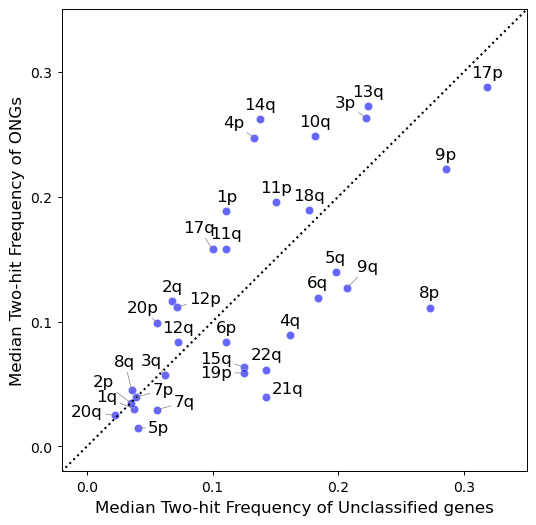

In [15]:
config_rcparams()

plt.figure(figsize=(6,6))

arms_to_annotate = {
    "19q": (15, -5),
    "9q": (15, 5),
    "4p": (-15, 0),
    "3p": (-15, 0),
    "16q": (10, 5),
    "17q": (-10, 5),
    "21q": (15, -5),
    "15q": (5, -3),
    "12p": (20, -5),
    "3q": (-10, 0),
    "20q": (-20, -8),
    "20p": (-10, 0),
    "1q": (-20, -2),
    "8q": (-5, 10),
    "5p": (15, -10),
    "7p": (20, -5),
    "7q": (20, -5),
    "2p": (-20, 5),
    "15q": (-20, -5),
    "19p": (-20, -10)
    
}


data = pd.concat([data1,data3])
data = data[data.role!='TSG'].groupby(['role','arm'])['2hitfreq'].median().to_frame().reset_index().pivot(index='arm',columns='role',values='2hitfreq').reset_index()
ax = sns.scatterplot(data=data,x='other',y='ONG', color='blue', alpha=0.6)

ax.plot([-10, 110], [-10, 110],color='k',linestyle=':')

sel=data
for _, row in sel.iterrows():
    x, y = row['other'], row['ONG']
    label = row['arm']
    dx, dy = (0, 5)  
    
    if label in arms_to_annotate:
        extra_dx, extra_dy = arms_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=12,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=12,
            ha="center", va="bottom",          
        )

plt.xlabel('Median Two-hit Frequency of Unclassified genes', fontsize=12)
plt.ylabel('Median Two-hit Frequency of ONGs', fontsize=12)
ax.set_xticks([0.0,0.1,0.2,0.3,0.4])
ax.set_yticks([0.0,0.1,0.2,0.3,0.4])
#plt.title('Median Two-hit Frequency')
plt.xlim(-0.02,0.35)
plt.ylim(-0.02,0.35)

print(stats.spearmanr(data['other'].values,data['ONG'].values, nan_policy='omit'))

plt.show()

---

# Fig S1D

In [16]:
# calculating tumor specific 2 hit frequencies

tmp = tcgazf_nosil.copy()
tumor2hitfreqs = tmp.groupby(['Hugo_Symbol','CODE','zygosity']).tissue.nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index=['Hugo_Symbol','CODE'],columns='zygosity',values='counts').fillna(0).reset_index()
tumor2hitfreqs['tot'] = tumor2hitfreqs['1-hit']+tumor2hitfreqs['2-hit']
print(len(tumor2hitfreqs))
tumor2hitfreqs = tumor2hitfreqs[tumor2hitfreqs.tot>=5]
print(len(tumor2hitfreqs))
tumor2hitfreqs['2hitfreq'] = tumor2hitfreqs['2-hit']/tumor2hitfreqs['tot']

print(len(tumor2hitfreqs))
tumor2hitfreqs = pd.merge(tumor2hitfreqs,roles, on='Hugo_Symbol', how='left')
print(len(tumor2hitfreqs))

print(tumor2hitfreqs[tumor2hitfreqs.role=='TSG'].Hugo_Symbol.nunique())
tmp = tumor2hitfreqs[tumor2hitfreqs.role=='TSG']

tumor2hitfreqs

211688
26886
26886
26886
118


,Hugo_Symbol,CODE,1-hit,2-hit,tot,2hitfreq,role
0,A1BG,UCEC,6.0,0.0,6.0,0.000000,other
1,A1CF,LUAD,5.0,0.0,5.0,0.000000,ambiguous
2,A1CF,LUSC,5.0,4.0,9.0,0.444444,ambiguous
3,A1CF,SKCM,17.0,5.0,22.0,0.227273,ambiguous
4,A2M,BLCA,7.0,0.0,7.0,0.000000,other
...,...,...,...,...,...,...,...
26881,ZZEF1,LUSC,2.0,5.0,7.0,0.714286,other
26882,ZZEF1,SKCM,11.0,7.0,18.0,0.388889,other
26883,ZZEF1,UCEC,18.0,1.0,19.0,0.052632,other
26884,ZZZ3,LUAD,4.0,2.0,6.0,0.333333,ambiguous


KstestResult(statistic=0.24452582905739417, pvalue=1.6904670030203775e-40, statistic_location=0.22916666666666666, statistic_sign=1)
KstestResult(statistic=0.23869231535931426, pvalue=7.663653143018418e-25, statistic_location=0.3, statistic_sign=1)


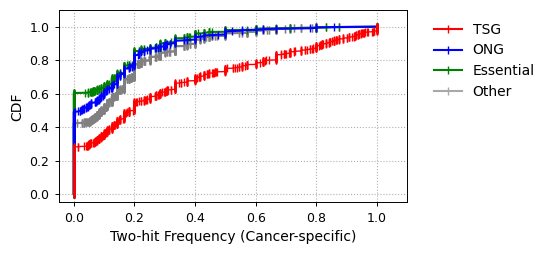

In [17]:
config_rcparams()

plt.figure(figsize=(4.5,2.5))

#data = tumor2hitfreqs[tumor2hitfreqs.role.isin(['other'])]['2hitfreq'].values
data = tumor2hitfreqs[tumor2hitfreqs.role=='nonessential']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', color='darkgrey') 

data = tumor2hitfreqs[tumor2hitfreqs.role.isin(['nonessential'])]['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', color='grey') 

data = tumor2hitfreqs[tumor2hitfreqs.role=='essential']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', color='green') 

data = tumor2hitfreqs[tumor2hitfreqs.role=='ONG']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', color='blue') 

data = tumor2hitfreqs[tumor2hitfreqs.role=='TSG']['2hitfreq'].values
sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cdf, marker='|', linestyle='-', linewidth=1, color='red', label='TSG') 

legend_elements = [Line2D([0], [0], linestyle='-', marker='|', color='red', label='TSG'),
                   Line2D([0], [0], linestyle='-', marker='|', color='blue', label='ONG'),
                   Line2D([0], [0], linestyle='-', marker='|', color='green', label='Essential'),
                   Line2D([0], [0], linestyle='-', marker='|', color='darkgrey', label='Other')]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.04, 1),frameon=False)

plt.grid(True, linestyle=':')
plt.xlim(-0.05,1.10)
plt.ylim(-0.05,1.10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('Two-hit Frequency (Cancer-specific)',fontsize=10)
plt.ylabel('CDF',fontsize=10)

print(stats.kstest(tumor2hitfreqs[tumor2hitfreqs.role.isin(['other','nonessential'])]['2hitfreq'].values,tumor2hitfreqs[tumor2hitfreqs.role=='TSG']['2hitfreq'].values))
print(stats.kstest(tumor2hitfreqs[tumor2hitfreqs.role.isin(['nonessential'])]['2hitfreq'].values,tumor2hitfreqs[tumor2hitfreqs.role=='TSG']['2hitfreq'].values))

plt.show()

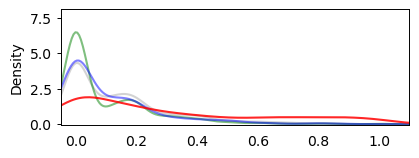

In [18]:
config_rcparams()

plt.figure(figsize=(4.5,1.5))

#data = tumor2hitfreqs[tumor2hitfreqs.role.isin(['other','nonessential'])]['2hitfreq'].values
data = tumor2hitfreqs[tumor2hitfreqs.role=='nonessential']['2hitfreq'].values
ax = sns.kdeplot(data, color='darkgrey', alpha=0.5)
data = tumor2hitfreqs[tumor2hitfreqs.role=='essential']['2hitfreq'].values
ax = sns.kdeplot(data, color='green', alpha=0.5)
data = tumor2hitfreqs[tumor2hitfreqs.role=='ONG']['2hitfreq'].values
ax = sns.kdeplot(data, color='blue', alpha=0.5)
data = tumor2hitfreqs[tumor2hitfreqs.role=='TSG']['2hitfreq'].values
ax = sns.kdeplot(data, color='red', alpha=0.85)

#plt.grid(True, linestyle=':')
plt.ylabel('Density',fontsize=10)
plt.xlim(-0.05,1.10)
plt.ylim(-0.05,8.10)
ax.tick_params(bottom=False) 

---